### Name: Riya Shyam Huddar
### Roll No.: MDS202431
### Quantum Portfolio Optimization: Assignment 4

### Load Predicted Returns

From Assignment 3 we obtained ML-predicted returns for assets.

Let

$$
r_i
$$

denote the predicted return for asset $i$.

We have two universes available:

- **Full Universe** - Nifty 50 assets
- **Extended Universe** - larger asset set

We load both datasets and then select which universe to use for the QUBO portfolio optimization.

In [1]:
import pandas as pd
import numpy as np

# Load predicted returns
mu_full_universe = pd.read_csv("ml_predictions_full_universe.csv")
mu_extended_universe = pd.read_csv("ml_predictions_extended_universe.csv")

print("Full universe size:", len(mu_full_universe))
print("Extended universe size:", len(mu_extended_universe))

Full universe size: 562
Extended universe size: 562


### Inspect Dataset Structure

We verify that the datasets contain:

- Asset identifiers
- Predicted returns

These values will be used to construct the return vector $r_i$.

In [3]:
mu_full_universe.head()

,Date,ADANIPORTS,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,...,TATAMOTORS,TATASTEEL,TCS,TECHM,TITAN,ULTRACEMCO,UPL,VEDL,WIPRO,ZEEL
0,2019-01-01,0.088575,0.105329,0.116347,0.116083,0.100023,0.095051,0.133317,0.092907,0.111688,...,0.111827,0.102693,0.122068,0.088926,0.085999,0.112034,0.114034,0.094014,0.106123,0.095896
1,2019-01-02,0.106512,0.112139,0.101756,0.118102,0.101933,0.091265,0.117594,0.085066,0.113869,...,0.118914,0.128010,0.108818,0.101994,0.102723,0.116233,0.122194,0.107970,0.123626,0.107192
2,2019-01-03,0.135027,0.104282,0.119401,0.135191,0.127329,0.118650,0.146769,0.122262,0.104894,...,0.148175,0.166173,0.106467,0.120674,0.091676,0.115791,0.113687,0.161443,0.122553,0.143701
3,2019-01-04,0.135958,0.106492,0.143539,0.121490,0.121442,0.127579,0.130413,0.122354,0.106792,...,0.147769,0.168174,0.122070,0.150258,0.111512,0.147883,0.136620,0.165769,0.126410,0.157833
4,2019-01-07,0.112823,0.109698,0.100200,0.108748,0.103095,0.120100,0.088551,0.092914,0.106867,...,0.101618,0.141419,0.127500,0.143278,0.111700,0.120010,0.115108,0.121750,0.127294,0.137366


In [5]:
mu_extended_universe.head()

,Date,ASIANPAINT,AXISBANK,BAJFINANCE,BHARTIARTL,BPCL,BRITANNIA,CIPLA,DRREDDY,EICHERMOT,...,SBIN,SHREECEM,SUNPHARMA,TATAMOTORS,TATASTEEL,TITAN,UPL,VEDL,WIPRO,ZEEL
0,2019-01-01,0.159511,0.146797,0.169349,0.195407,0.191426,0.141098,0.146232,0.143760,0.166348,...,0.147853,0.162771,0.159959,0.164378,0.136538,0.119253,0.163710,0.156167,0.144542,0.121611
1,2019-01-02,0.168043,0.136255,0.173666,0.170008,0.188088,0.153560,0.139137,0.153481,0.161010,...,0.140021,0.169130,0.163614,0.177438,0.152753,0.128249,0.182854,0.147186,0.156422,0.152577
2,2019-01-03,0.166139,0.150577,0.184911,0.198717,0.194182,0.145449,0.140518,0.142650,0.218672,...,0.162859,0.158322,0.175636,0.192374,0.166222,0.125609,0.164886,0.170929,0.136202,0.193293
3,2019-01-04,0.181041,0.183473,0.199397,0.190423,0.193434,0.156883,0.136085,0.155611,0.196319,...,0.174735,0.176834,0.205388,0.190938,0.161858,0.143771,0.182125,0.168595,0.141690,0.202168
4,2019-01-07,0.199934,0.155566,0.198481,0.177684,0.179958,0.169404,0.133009,0.146671,0.179094,...,0.157479,0.191984,0.199340,0.167702,0.141740,0.152295,0.172519,0.137353,0.152198,0.192692


### Construct Return Vector

The ML model from Assignment 3 generated predicted returns for each asset at the **rebalance date**.

Let $r_i$ denote the predicted return of asset $i$.

Thus the return vector is

$$
r = [r_1, r_2, \dots, r_N]
$$

where $N$ is the number of assets in the universe.

In [7]:
# remove date column
returns_full = mu_full_universe.drop(columns=["Date"])
returns_extended = mu_extended_universe.drop(columns=["Date"])

# extract predicted returns (single row)
r_full = returns_full.iloc[0].values
r_extended = returns_extended.iloc[0].values

# asset names
assets_full = returns_full.columns.values
assets_extended = returns_extended.columns.values

# number of assets
N_full = len(r_full)
N_extended = len(r_extended)

print("Full universe assets:", N_full)
print("Extended universe assets:", N_extended)

Full universe assets: 50
Extended universe assets: 38


----

### Decision Variables and Portfolio Constraint

We define binary decision variables:

$$
x_i =
\begin{cases}
1 & \text{if asset } i \text{ is selected} \\
0 & \text{otherwise}
\end{cases}
$$

The goal is to construct a portfolio containing **exactly 10 assets**.

Therefore, we impose the cardinality constraint

$$
\sum_{i=1}^{N} x_i = 10
$$

where:

- $N$ = number of assets in the universe
- $x_i$ = decision variable for asset $i$

The portfolio return is given by

$$
\max_x \sum_{i=1}^{N} r_i x_i
$$

However, QUBO problems require an **unconstrained quadratic objective**.  
Therefore, this constraint will be converted into a **penalty term** in the next step.

In [9]:
# Number of assets to select
K = 10

print("Portfolio size constraint:", K)

Portfolio size constraint: 10


### Convert the Constraint into a Penalty

QUBO problems must be **unconstrained** and contain only **binary variables with linear and quadratic terms**.

Our constraint is

$$
\sum_{i=1}^{N} x_i = 10
$$

To enforce this constraint we introduce a **quadratic penalty function**:

$$
\lambda \left(\sum_{i=1}^{N} x_i - 10\right)^2
$$

where:

- $\lambda > 0$ is a penalty coefficient
- larger $\lambda$ penalizes violations of the constraint more strongly

If the constraint is satisfied, the penalty equals **0**.  
If the constraint is violated, the objective increases.

The optimization objective becomes

$$
\min_x -\sum_{i=1}^{N} r_i x_i + \lambda \left(\sum_{i=1}^{N} x_i - 10\right)^2
$$

We convert maximization into minimization by negating the return term.

In [11]:
# compute average magnitude of returns
avg_r_full = np.mean(np.abs(r_full))
avg_r_extended = np.mean(np.abs(r_extended))

# choose penalty parameter
lam_full = 10 * avg_r_full
lam_extended = 10 * avg_r_extended

print("Lambda (full universe):", lam_full)
print("Lambda (extended universe):", lam_extended)

Lambda (full universe): 1.0707830150509936
Lambda (extended universe): 1.533378529530835


### Expand the Penalty Term

The penalty term enforcing the portfolio size constraint is

$$
\lambda \left(\sum_{i=1}^{N} x_i - 10\right)^2
$$

Expanding the square:

$$
\left(\sum_{i=1}^{N} x_i - 10\right)^2
=
\left(\sum_{i=1}^{N} x_i\right)^2
- 20\sum_{i=1}^{N} x_i
+ 100
$$

Next expand the first term:

$$
\left(\sum_{i=1}^{N} x_i\right)^2
=
\sum_{i=1}^{N} x_i^2
+
2\sum_{i<j} x_i x_j
$$

Since the variables are binary,

$$
x_i^2 = x_i
$$

Thus the penalty becomes

$$
\sum_{i=1}^{N} x_i
+
2\sum_{i<j} x_i x_j
-
20\sum_{i=1}^{N} x_i
+
100
$$

Simplifying:

$$
-19\sum_{i=1}^{N} x_i
+
2\sum_{i<j} x_i x_j
+
100
$$

The constant term **100 does not affect optimization** and can be ignored.

Therefore the full QUBO objective becomes

$$
\min_x
-
\sum_{i=1}^{N} r_i x_i
+
\lambda
\left(
-19\sum_{i=1}^{N} x_i
+
2\sum_{i<j} x_i x_j
\right)
$$

From this we obtain the QUBO coefficients:

Diagonal terms:

$$
Q_{ii} = -r_i - 19\lambda
$$

Off-diagonal terms:

$$
Q_{ij} = 2\lambda \quad (i \ne j)
$$

In [13]:
# build QUBO matrix for full universe

Q_full = np.zeros((N_full, N_full))

# diagonal terms
for i in range(N_full):
    Q_full[i, i] = -r_full[i] - 19 * lam_full

# off-diagonal terms
for i in range(N_full):
    for j in range(i+1, N_full):
        Q_full[i, j] = 2 * lam_full
        Q_full[j, i] = 2 * lam_full

print("Q matrix shape (full):", Q_full.shape)

Q matrix shape (full): (50, 50)


In [15]:
Q_extended = np.zeros((N_extended, N_extended))

for i in range(N_extended):
    Q_extended[i, i] = -r_extended[i] - 19 * lam_extended

for i in range(N_extended):
    for j in range(i+1, N_extended):
        Q_extended[i, j] = 2 * lam_extended
        Q_extended[j, i] = 2 * lam_extended

print("Q matrix shape (extended):", Q_extended.shape)

Q matrix shape (extended): (38, 38)


----

### QUBO Objective Function

The QUBO problem can be written in quadratic form:

$$
\min_x \; x^T Q x
$$

where:

- $x \in \{0,1\}^N$ is the binary decision vector
- $Q$ is the QUBO matrix constructed earlier

The quantity $x^T Q x$ is called the **QUBO energy**.  
The optimization problem consists of finding the binary vector $x$ that minimizes this energy.

In [379]:
def qubo_energy(x, Q):
    x = np.array(x)
    # upper triangle only
    return x @ np.triu(Q) @ x

### Option (A): Reduced Problem for Brute Force

Brute force requires evaluating all possible binary configurations.

For $N$ assets there are:

$$
2^N
$$

possible portfolios.

To make this feasible, we restrict the universe to the **first 15 assets**, giving

$$
2^{15} = 32768
$$

possible portfolios.

In [351]:
N_small = 15

Q_small = Q_full[:N_small, :N_small]
assets_small = assets_full[:N_small]
r_small = r_full[:N_small]

In [353]:
N_small_ext = 15

Q_small_ext = Q_extended[:N_small_ext, :N_small_ext]
assets_small_ext = assets_extended[:N_small_ext]
r_small_ext = r_extended[:N_small_ext]

### Brute Force Optimization

We enumerate all binary vectors of length $N_{small}$ and compute the QUBO energy.

Only portfolios satisfying

$$
\sum_i x_i = 10
$$

are considered valid.

In [355]:
import itertools

best_energy = float("inf")
best_x = None

for x in itertools.product([0,1], repeat=N_small):

    energy = qubo_energy(x, Q_small)

    if energy < best_energy:
        best_energy = energy
        best_x = x

selected_assets = sum(best_x)

print("Best energy:", best_energy)
print("Number of selected assets:", selected_assets)

Best energy: -108.26993656209186
Number of selected assets: 10


In [357]:
best_energy_ext = float("inf")
best_x_ext = None

for x in itertools.product([0,1], repeat=N_small_ext):

    energy = qubo_energy(x, Q_small_ext)

    if energy < best_energy_ext:
        best_energy_ext = energy
        best_x_ext = x

selected_assets_ext = sum(best_x_ext)

print("Best energy (extended):", best_energy_ext)
print("Number of selected assets:", selected_assets_ext)

Best energy (extended): -155.02304199321043
Number of selected assets: 10


### Selected Portfolio

### Comparison with Top Assets by Predicted Return (Reduced Universes)

For the reduced asset universes used in the brute-force experiments, the optimal portfolios obtained from the QUBO formulation were compared with the assets ranked purely by predicted return.

#### Reduced Full Universe

Number of common assets: **10**

Common assets:
`CIPLA`, `BHARTIARTL`, `GRASIM`, `BAJAJ-AUTO`, `EICHERMOT`, `ASIANPAINT`, `DRREDDY`, `BRITANNIA`, `AXISBANK`, `COALINDIA`

#### Reduced Extended Universe

Number of common assets: **10**

Common assets:
`BPCL`, `AXISBANK`, `BHARTIARTL`, `HEROMOTOCO`, `EICHERMOT`, `ASIANPAINT`, `DRREDDY`, `CIPLA`, `GAIL`, `BAJFINANCE`

#### Observation

In both reduced universes, the brute-force QUBO solution selects exactly the same assets as the top-10 assets ranked by predicted return. This is expected because once the cardinality constraint is satisfied, the objective effectively reduces to maximizing the sum of expected returns.

Since brute-force enumeration evaluates **all possible portfolios** in the reduced universe, it guarantees that the resulting portfolio is the **global optimum** of the QUBO formulation.

In [359]:
selected_assets_full = [assets_small[i] for i in range(N_small) if best_x[i] == 1]

pd.DataFrame({
    "Selected Assets (Full Universe)": selected_assets_full
})

,Selected Assets (Full Universe)
0,ASIANPAINT
1,AXISBANK
2,BAJAJ-AUTO
3,BHARTIARTL
4,BRITANNIA
5,CIPLA
6,COALINDIA
7,DRREDDY
8,EICHERMOT
9,GRASIM


In [361]:
df_full = pd.DataFrame({
    "Asset": assets_small,
    "Predicted Return": r_small
})

df_full_sorted = df_full.sort_values(by="Predicted Return", ascending=False)

top_assets = df_full_sorted.head(10)

print("Top assets by predicted return (reduced full universe):")
top_assets

Top assets by predicted return (reduced full universe):


,Asset,Predicted Return
6,BHARTIARTL,0.133317
10,COALINDIA,0.130281
9,CIPLA,0.122616
12,EICHERMOT,0.119897
11,DRREDDY,0.119375
14,GRASIM,0.116702
2,AXISBANK,0.116347
3,BAJAJ-AUTO,0.116083
8,BRITANNIA,0.111688
1,ASIANPAINT,0.105329


In [363]:
selected_set = set(selected_assets_full)
top_set = set(top_assets["Asset"])

common_assets = selected_set.intersection(top_set)

print("Number of common assets:", len(common_assets))
print("Common assets:", common_assets)

Number of common assets: 10
Common assets: {'CIPLA', 'BHARTIARTL', 'GRASIM', 'BAJAJ-AUTO', 'EICHERMOT', 'ASIANPAINT', 'DRREDDY', 'BRITANNIA', 'AXISBANK', 'COALINDIA'}


In [365]:
import pandas as pd

selected_assets_ext = [assets_small_ext[i] for i in range(N_small_ext) if best_x_ext[i] == 1]

pd.DataFrame({
    "Selected Assets (Extended Universe)": selected_assets_ext
})

,Selected Assets (Extended Universe)
0,ASIANPAINT
1,AXISBANK
2,BAJFINANCE
3,BHARTIARTL
4,BPCL
5,CIPLA
6,DRREDDY
7,EICHERMOT
8,GAIL
9,HEROMOTOCO


In [367]:
df_ext = pd.DataFrame({
    "Asset": assets_small_ext,
    "Predicted Return": r_small_ext
})

df_ext_sorted = df_ext.sort_values(by="Predicted Return", ascending=False)

top_assets_ext = df_ext_sorted.head(10)

print("Top assets by predicted return (reduced extended universe):")
top_assets_ext

Top assets by predicted return (reduced extended universe):


,Asset,Predicted Return
14,HEROMOTOCO,0.196517
3,BHARTIARTL,0.195407
4,BPCL,0.191426
9,GAIL,0.169841
2,BAJFINANCE,0.169349
8,EICHERMOT,0.166348
0,ASIANPAINT,0.159511
1,AXISBANK,0.146797
6,CIPLA,0.146232
7,DRREDDY,0.143760


In [369]:
selected_set_ext = set(selected_assets_ext)
top_set_ext = set(top_assets_ext["Asset"])

common_assets_ext = selected_set_ext.intersection(top_set_ext)

print("Number of common assets:", len(common_assets_ext))
print("Common assets:", common_assets_ext)

Number of common assets: 10
Common assets: {'BPCL', 'AXISBANK', 'BHARTIARTL', 'HEROMOTOCO', 'EICHERMOT', 'ASIANPAINT', 'DRREDDY', 'CIPLA', 'GAIL', 'BAJFINANCE'}


### Verify the Cardinality Constraint

The portfolio construction requires selecting exactly **10 assets**.
$$
\sum_{i=1}^{N} x_i = 10
$$

In [371]:
print("Number of selected assets (full):", sum(best_x))
print("Number of selected assets (extended):", sum(best_x_ext))

Number of selected assets (full): 10
Number of selected assets (extended): 10


### Effect of the Penalty Parameter λ (Brute Force)

To understand the effect of the penalty parameter λ, we solve the QUBO exactly using brute force on the reduced asset set.

For each λ we compute the optimal solution

$$
\min_x x^T Q x
$$

and record the number of selected assets

$$
k = \sum_i x_i
$$

This allows us to observe how the penalty strength influences the enforcement of the cardinality constraint.

In [373]:
lambda_values = np.linspace(0.005, 2, 25)

k_values = []
energy_values = []
return_values = []

for lam in lambda_values:

    Q = np.zeros((N_small, N_small))

    for i in range(N_small):
        Q[i,i] = -r_small[i] - 19*lam

    for i in range(N_small):
        for j in range(i+1, N_small):
            Q[i,j] = 2*lam
            Q[j,i] = 2*lam

    best_energy = float("inf")
    best_x = None

    for x in itertools.product([0,1], repeat=N_small):

        energy = qubo_energy(x, Q)

        if energy < best_energy:
            best_energy = energy
            best_x = x

    k_values.append(sum(best_x))
    energy_values.append(best_energy)

    # compute portfolio return
    portfolio_return = sum(r_small[i] for i in range(N_small) if best_x[i] == 1)
    return_values.append(portfolio_return)

### Effect of λ on QUBO Solution

Three experiments were performed to analyze the effect of the penalty parameter $(\lambda)$ on the QUBO formulation.

**1. Portfolio Size vs $(\lambda)$**  
For very small $(\lambda)$, the penalty term is weak and the optimizer selects many assets since most predicted returns are positive. As $(\lambda)$ increases, the number of selected assets decreases and stabilizes around **10 assets**, which satisfies the cardinality constraint.

**2. Energy vs $(\lambda)$**  
The minimum QUBO energy decreases approximately linearly with $(\lambda)$. This occurs because the expanded penalty introduces a constant shift proportional to $(\lambda)$ in the objective function. The overall trend indicates that the constraint is being enforced consistently.

**3. Portfolio Return vs $(\lambda)$**  
For very small $(\lambda)$, the optimizer selects many assets, resulting in a **higher total return** since most predicted returns are positive. As $(\lambda)$ increases and the constraint becomes stronger, the number of selected assets decreases to **10**, causing the portfolio return to **drop and then stabilize**. Once the constraint is enforced, the return remains relatively constant because the optimal 10-asset portfolio does not change significantly for larger values of $(\lambda)$.

**4. Energy Landscape vs Portfolio Size**  
The energy landscape shows the minimum energy achievable for each portfolio size $(k)$. The global minimum occurs at **$(k \approx 10)$** assets, confirming that the optimal portfolio under the QUBO formulation satisfies the desired cardinality.



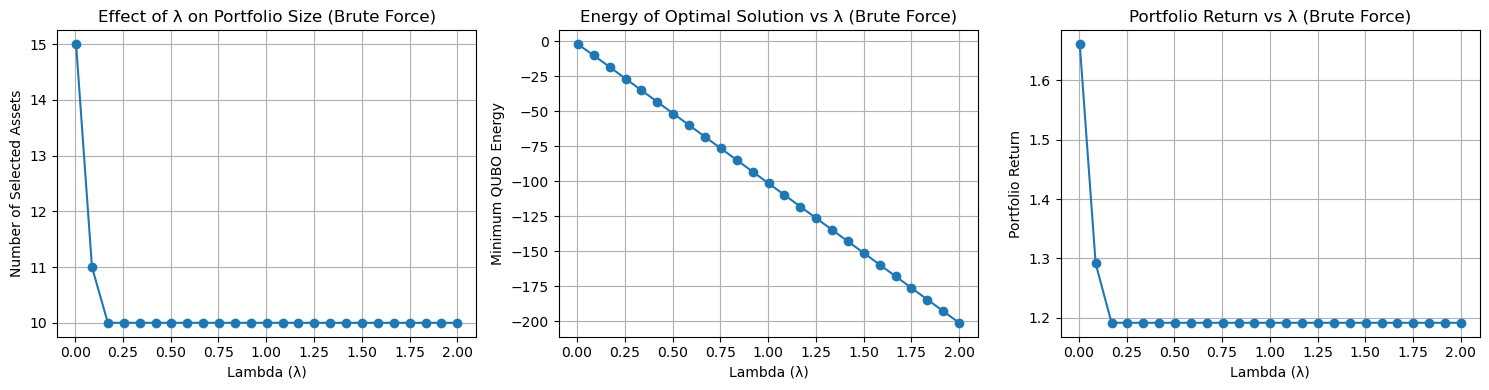

In [375]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

# Plot 1: lambda vs selected assets
plt.subplot(1,3,1)
plt.plot(lambda_values, k_values, marker="o")
plt.xlabel("Lambda (λ)")
plt.ylabel("Number of Selected Assets")
plt.title("Effect of λ on Portfolio Size (Brute Force)")
plt.grid(True)

# Plot 2: lambda vs energy
plt.subplot(1,3,2)
plt.plot(lambda_values, energy_values, marker="o")
plt.xlabel("Lambda (λ)")
plt.ylabel("Minimum QUBO Energy")
plt.title("Energy of Optimal Solution vs λ (Brute Force)")
plt.grid(True)

# Plot 3: lambda vs portfolio return
plt.subplot(1,3,3)
plt.plot(lambda_values, return_values, marker="o")
plt.xlabel("Lambda (λ)")
plt.ylabel("Portfolio Return")
plt.title("Portfolio Return vs λ (Brute Force)")
plt.grid(True)

plt.tight_layout()
plt.show()

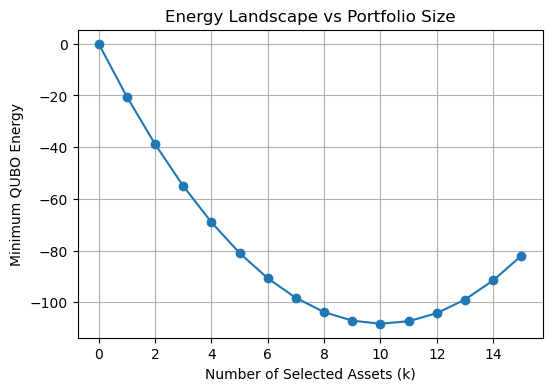

In [377]:
energy_by_k = {k: float("inf") for k in range(N_small + 1)}

for x in itertools.product([0,1], repeat=N_small):

    k = sum(x)
    energy = qubo_energy(x, Q_small)

    if energy < energy_by_k[k]:
        energy_by_k[k] = energy


k_vals = list(energy_by_k.keys())
energy_vals = list(energy_by_k.values())


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(k_vals, energy_vals, marker='o')

plt.xlabel("Number of Selected Assets (k)")
plt.ylabel("Minimum QUBO Energy")
plt.title("Energy Landscape vs Portfolio Size")

plt.grid(True)
plt.show()

---

### Option (B): Simulated Annealing Solver

Brute force search becomes infeasible for large problems since the number of possible portfolios grows exponentially.

For example, with 50 assets:

$$
2^{50} \approx 1.12 \times 10^{15}
$$

possible binary portfolios exist.

Therefore we use **simulated annealing**, a stochastic optimization algorithm that approximately minimizes the QUBO objective

$$
\min_x x^T Q x
$$

by exploring the search space through random perturbations and gradually reducing the probability of accepting worse solutions.

In [ ]:
!pip install dwave-neal

In [60]:
import neal
import dimod

### Convert QUBO Matrix to Dictionary

The simulated annealing solver expects the QUBO to be provided as a dictionary of coefficients.

Each entry corresponds to a quadratic coefficient:

$$
Q_{ij}
$$

represented as
$(i, j) -> Q_ij$


We convert the QUBO matrices for both the **full universe** and the **extended universe** into this format.


In [381]:
def qubo_to_dict(Q):
    i_idx, j_idx = np.triu_indices_from(Q)
    mask = Q[i_idx, j_idx] != 0
    return {(i, j): Q[i, j] for i, j in zip(i_idx[mask], j_idx[mask])}

In [383]:
Q_dict_full = qubo_to_dict(Q_full)
Q_dict_extended = qubo_to_dict(Q_extended)

print("Full QUBO dictionary size:", len(Q_dict_full))
print("Extended QUBO dictionary size:", len(Q_dict_extended))

Full QUBO dictionary size: 1275
Extended QUBO dictionary size: 741


### Initialize Simulated Annealing

We use the **SimulatedAnnealingSampler** to approximately minimize the QUBO objective.

Multiple independent runs (reads) are performed to increase the chance of finding a low-energy solution.

In [385]:
sampler = neal.SimulatedAnnealingSampler()

In [387]:
sampleset_full = sampler.sample_qubo(Q_dict_full, num_reads=1000)

best_sample_full = sampleset_full.first.sample

In [388]:
sampleset_extended = sampler.sample_qubo(Q_dict_extended, num_reads=1000)

best_sample_extended = sampleset_extended.first.sample

### Extract Selected Assets

The simulated annealing solver returns a binary vector representing the optimal portfolio.

Assets with

$$
x_i = 1
$$

are selected for the portfolio.

In [391]:
import pandas as pd

selected_assets_sa_full = [
    assets_full[i] for i in range(N_full) if best_sample_full[i] == 1
]

selected_returns_sa_full = [
    r_full[i] for i in range(N_full) if best_sample_full[i] == 1
]

df_sa_full = pd.DataFrame({
    "Asset": selected_assets_sa_full,
    "Expected Return": selected_returns_sa_full
})

df_sa_full

,Asset,Expected Return
0,BAJAJ-AUTO,0.116083
1,BHARTIARTL,0.133317
2,CIPLA,0.122616
3,COALINDIA,0.130281
4,HEROMOTOCO,0.131330
5,IOC,0.118519
6,KOTAKBANK,0.122422
7,LT,0.102976
8,TCS,0.122068
9,ZEEL,0.095896


In [393]:
print(len(df_sa_full))

10


### Comparison with Top-10 Return Portfolio (Full Nifty 50 Universe)

For the full asset universe, the portfolio obtained using simulated annealing was compared with a baseline portfolio constructed by selecting the **top-10 assets ranked by expected return**.

| Portfolio | Total Return |
|----------|--------------|
| Top-10 by Expected Return | 1.2766 |
| Simulated Annealing Portfolio | 1.2049 |

The simulated annealing solution achieves a slightly lower total return than the greedy top-10 portfolio. This is expected because simulated annealing is a **stochastic heuristic optimization method** and does not guarantee finding the global optimum.

Even so, the simulated annealing portfolio captures most of the optimal value, achieving approximately **94% of the maximum possible return** while satisfying the constraint of selecting **exactly 10 assets**.

The two portfolios share **6 common assets**, indicating that the QUBO formulation successfully prioritizes many of the highest-return assets while still exploring alternative feasible combinations within the full Nifty 50 universe.

In [395]:
df_returns_full = pd.DataFrame({
    "Asset": assets_full,
    "Expected Return": r_full
})

top10_returns = df_returns_full.sort_values(
    by="Expected Return", ascending=False
).head(10)

top10_returns

,Asset,Expected Return
39,SUNPHARMA,0.145806
6,BHARTIARTL,0.133317
18,HEROMOTOCO,0.131330
10,COALINDIA,0.130281
29,MARUTI,0.129494
9,CIPLA,0.122616
27,KOTAKBANK,0.122422
42,TCS,0.122068
12,EICHERMOT,0.119897
11,DRREDDY,0.119375


In [397]:
top10_set = set(top10_returns["Asset"])
sa_set = set(df_sa_full["Asset"])

common_assets = top10_set.intersection(sa_set)

print("Number of common assets:", len(common_assets))
print("Common assets:", common_assets)

Number of common assets: 6
Common assets: {'TCS', 'BHARTIARTL', 'KOTAKBANK', 'CIPLA', 'HEROMOTOCO', 'COALINDIA'}


In [399]:
return_top10 = top10_returns["Expected Return"].sum()
return_sa = df_sa_full["Expected Return"].sum()

print("Top-10 return portfolio:", return_top10)
print("SA portfolio:", return_sa)

Top-10 return portfolio: 1.2766050497759407
SA portfolio: 1.1955063198837323


In [401]:
selected_indices_ext = [
    i for i in range(N_extended) if best_sample_extended[i] == 1
]

selected_assets_sa_ext = [
    assets_extended[i] for i in selected_indices_ext
]

selected_returns_sa_ext = [
    r_extended[i] for i in selected_indices_ext
]

df_sa_extended = pd.DataFrame({
    "Index": selected_indices_ext,
    "Asset": selected_assets_sa_ext,
    "Expected Return": selected_returns_sa_ext
}).sort_values(by="Expected Return", ascending=False)

df_sa_extended

,Index,Asset,Expected Return
5,22,KOTAKBANK,0.220031
1,3,BHARTIARTL,0.195407
2,4,BPCL,0.191426
7,24,MM,0.179426
4,20,IOC,0.174544
3,9,GAIL,0.169841
8,29,SHREECEM,0.162771
0,0,ASIANPAINT,0.159511
6,23,MARUTI,0.159341
9,35,VEDL,0.156167


In [403]:
print(len(df_sa_extended))

10


### Comparison with Top-10 Return Portfolio (Extended Universe)

For the extended asset universe, the portfolio obtained using simulated annealing was compared with a baseline portfolio formed by selecting the **top-10 assets ranked by expected return**.

| Portfolio | Total Return |
|----------|--------------|
| Top-10 by Expected Return | 1.8610 |
| Simulated Annealing Portfolio | 1.7866 |

The simulated annealing portfolio achieves a slightly lower total return than the greedy top-10 portfolio. This is expected because simulated annealing is a **stochastic heuristic optimization method** and does not guarantee finding the exact global optimum.

Despite this, the simulated annealing solution captures most of the optimal value, achieving approximately **96% of the maximum possible return** while satisfying the constraint of selecting **exactly 10 assets**.

The two portfolios share **6 common assets** (`BPCL`, `BHARTIARTL`, `IOC`, `KOTAKBANK`, `MM`, `HEROMOTOCO`).  
This overlap indicates that the QUBO formulation successfully identifies many of the highest-return assets while still exploring alternative feasible combinations within the extended asset universe.

In [407]:
df_returns_extended = pd.DataFrame({
    "Asset": assets_extended,
    "Expected Return": r_extended
})

top10_extended = df_returns_extended.sort_values(
    by="Expected Return", ascending=False
).head(10)

top10_extended

,Asset,Expected Return
22,KOTAKBANK,0.220031
14,HEROMOTOCO,0.196517
3,BHARTIARTL,0.195407
4,BPCL,0.191426
26,ONGC,0.186154
24,MM,0.179426
16,HINDUNILVR,0.178343
20,IOC,0.174544
9,GAIL,0.169841
2,BAJFINANCE,0.169349


In [409]:
top10_set_ext = set(top10_extended["Asset"])
sa_set_ext = set(df_sa_extended["Asset"])

common_assets_ext = top10_set_ext.intersection(sa_set_ext)

print("Number of common assets:", len(common_assets_ext))
print("Common assets:", common_assets_ext)

Number of common assets: 6
Common assets: {'BPCL', 'BHARTIARTL', 'IOC', 'KOTAKBANK', 'MM', 'GAIL'}


In [411]:
return_top10_ext = top10_extended["Expected Return"].sum()
return_sa_ext = df_sa_extended["Expected Return"].sum()

print("Top-10 return portfolio:", return_top10_ext)
print("SA portfolio:", return_sa_ext)

Top-10 return portfolio: 1.8610398543780136
SA portfolio: 1.7684666141748577


-----

### Effect of the Penalty Parameter λ

The penalty parameter λ determines how strongly the cardinality constraint

$$
\sum_{i=1}^{N} x_i = 10
$$

is enforced.

To study its effect, we solve the QUBO using simulated annealing for different values of λ and observe:

- number of selected assets  
- resulting portfolio return  
- QUBO energy  

**Observations**

- When **λ is too small (λ = 0.1)**, the penalty is weak and the optimizer selects **more than 10 assets**.
- For **moderate values of λ (≥ 0.5)**, the constraint is enforced and the solution contains **exactly 10 assets**.
- As **λ increases**, the energy becomes more negative due to the constant penalty shift, while the portfolio return remains relatively stable but shows slight decreasing trend.

This demonstrates that choosing a sufficiently large penalty parameter ensures the cardinality constraint is satisfied while still allowing the optimization to prioritize high-return assets.

In [429]:
def build_qubo(r, lam):
    N = len(r)
    Q = np.full((N, N), 2 * lam)
    np.fill_diagonal(Q, -r - 19 * lam)  # vectorized
    return Q

In [431]:
lambda_values = [0.1, 0.5, 1, 2, 5, 10, 20, 100]

results_sa = []

for lam in lambda_values:

    Q = build_qubo(r_full, lam)
    Q_dict = qubo_to_dict(Q)

    sampleset = sampler.sample_qubo(Q_dict, num_reads=1000)
    best_sample = sampleset.first.sample
    best_energy = sampleset.first.energy

    x = np.array([best_sample[i] for i in range(len(r_full))])

    num_assets = x.sum()
    portfolio_return = np.dot(r_full, x)

    results_sa.append({
        "lambda": lam,
        "energy": best_energy,
        "num_assets": num_assets,
        "portfolio_return": portfolio_return
    })

In [434]:
df_lambda_sa = pd.DataFrame(results_sa)

df_lambda_sa

,lambda,energy,num_assets,portfolio_return
0,0.1,-11.278048,11,1.378048
1,0.5,-51.215227,10,1.215227
2,1.0,-100.000000,10,1.089015
3,2.0,-200.000000,10,1.068914
4,5.0,-500.000000,10,1.064958
5,10.0,-1000.000000,10,1.094819
6,20.0,-2000.000000,10,1.085624
7,100.0,-10000.000000,10,1.065862


----

### What happens if λ is too small?

If the penalty parameter λ is too small, the penalty term

$$
\lambda \left(\sum_{i=1}^{N} x_i - 10 \right)^2
$$

does not strongly enforce the cardinality constraint. As a result, the optimizer focuses primarily on maximizing expected returns and may select **more than 10 assets**.

This behavior was observed in the experiments.  
- In the **simulated annealing experiment**, when λ = 0.1, the solver selected **11 assets** instead of 10.  
- In the **brute-force experiment on the reduced universe**, when λ = 0.005, the optimal solution selected **15 assets**, meaning the constraint was completely ignored.

Because the penalty was too weak, the optimizer preferred adding additional assets with positive expected returns rather than strictly satisfying the constraint.

Therefore, λ must be chosen sufficiently large so that violating the constraint becomes more costly than the additional return gained from selecting extra assets.

### What happens if λ is too large?

If the penalty parameter λ is extremely large, the penalty term dominates the objective function. In this case, the optimization focuses almost entirely on satisfying the constraint

$$
\sum_{i=1}^{N} x_i = 10
$$

while the return term $(-\sum r_i x_i)$ becomes relatively insignificant.

As a result, many portfolios that satisfy the constraint may have very similar objective values, and the optimizer may select solutions that are not the best in terms of return. This can lead to **slightly lower portfolio returns** even though the constraint is satisfied.

This behavior is reflected in the experiments: for larger values of λ, the number of selected assets remains **exactly 10**, but the **portfolio return fluctuates slightly and can decrease**, since the optimization is driven more by constraint satisfaction than by maximizing returns.

Therefore, λ should be chosen **large enough to enforce the constraint**, but not excessively large so that it overwhelms the objective.

### Why does this formulation produce quadratic interactions?

Quadratic interactions arise from expanding the penalty term used to enforce the cardinality constraint:

$$
\lambda \left(\sum_{i=1}^{N} x_i - 10 \right)^2
$$

Expanding the square gives

$$
\left(\sum_{i=1}^{N} x_i - 10\right)^2
=
\sum_{i=1}^{N} x_i
+ 2 \sum_{i<j} x_i x_j
- 20 \sum_{i=1}^{N} x_i
+ 100
$$

The important term is

$$
2 \sum_{i<j} x_i x_j
$$

which introduces **pairwise interactions between decision variables**.

These quadratic terms penalize selecting too many assets simultaneously, because every pair of selected assets contributes an additional penalty. This mechanism allows the optimization problem to enforce the constraint using only **binary variables and quadratic terms**, which is exactly the structure required for a **QUBO (Quadratic Unconstrained Binary Optimization) formulation**.

### How would you add risk (covariance matrix Σ) to this QUBO?

Portfolio risk can be incorporated using the covariance matrix Σ of asset returns.  
In classical portfolio optimization, risk is often measured as

$$
x^T \Sigma x
$$

which represents the variance of the portfolio.

To include risk in the QUBO formulation, we can modify the objective function to balance **return and risk**:

$$
\min_x \left( -\sum_{i=1}^{N} r_i x_i + \gamma \, x^T \Sigma x + \lambda \left(\sum_{i=1}^{N} x_i - 10\right)^2 \right)
$$

where:

- $(r_i)$ = expected return of asset $(i)$
- $(\Sigma)$ = covariance matrix of asset returns
- $(\gamma)$ = risk-aversion parameter
- $(\lambda)$ = penalty enforcing the cardinality constraint

The term $(x^T \Sigma x)$ naturally produces **quadratic interactions between assets**, since the covariance between assets $(i)$ and $(j)$ contributes a term $(\Sigma_{ij} x_i x_j)$.

Thus, adding risk fits naturally within the QUBO framework because both the **risk term** and the **penalty term** already produce quadratic interactions between binary decision variables.

----